## Optimization Problem Formulation

We solve a simulation-based optimization problem to determine the optimal operating conditions of the PSA process. The goal is to maximize process productivity while satisfying constraints on product purity, recovery, and cyclic steady-state (CSS) convergence.

The decision variables are defined as

$$
x =
(L,\; P_0,\; \dot{n},\; t_{ads},\; \alpha,\; \beta,\; P_I,\; P_l)
$$

where

| Variable | Meaning |
|--------|--------|
| L | column length |
| P0 | adsorption pressure |
| ndot | feed flow rate |
| tads | adsorption time |
| alpha | pressurization fraction |
| beta | purge fraction |
| PI | intermediate pressure |
| Pl | low pressure |

Each variable is bounded within physically meaningful limits.

---

## Objective Function

The primary objective is to maximize the PSA productivity while optionally penalizing energy consumption.

$$
\max_x f(x)
$$

where

$$
f(x) =
\text{Productivity}(x) -
w_E \cdot \text{Energy}(x)
$$

In the current experiments the energy penalty weight $w_E$ is set to zero, so the optimization effectively maximizes productivity.

---

## Process Constraints

The optimization is subject to several process constraints.

### Purity constraint

$$
\text{Purity}(x) \ge P_{min}
$$

which is implemented as

$$
g_1(x) =
P_{min} - \text{Purity}(x) \le 0
$$

---

### Recovery constraint

$$
\text{Recovery}(x) \ge R_{min}
$$

implemented as

$$
g_2(x) =
R_{min} - \text{Recovery}(x) \le 0
$$

---

### Cyclic steady state (CSS)

The PSA cycle must reach cyclic steady state.

$$
g_3(x) =
CSS(x) - \epsilon_{css} \le 0
$$

where $CSS(x)$ measures the difference between consecutive cycles.

---

### Pressure ordering constraints

To ensure physically meaningful operation, the pressure levels must satisfy

$$
P_I \le P_0
$$

$$
P_l \le P_I
$$

---

## Optimization Method

Because the PSA model is evaluated through a cycle simulation, analytical gradients are not available. Therefore, we use a **trust-region sequential linear programming (SLP)** approach.

At each iteration:

1. The PSA cycle simulator evaluates the current operating point.
2. Gradients of the objective and constraints are estimated using finite differences.
3. A linearized trust-region subproblem is constructed.
4. The subproblem is solved using a linear programming solver.
5. The trust-region radius is updated depending on the improvement of the solution.

The LP subproblem is solved using the **GLPK solver** through Pyomo.

---

## Optimization Algorithm Workflow

The optimization procedure follows a trust-region sequential linear programming (SLP) framework applied to a simulation-based PSA process model.

The overall workflow of the algorithm is illustrated below.


Initial guess $x_0$  
↓  
PSA cycle simulation  
↓  
Evaluate objective and constraints  
↓  
Finite difference gradient estimation  
↓  
Construct trust-region LP subproblem  
↓  
Solve LP (Pyomo + GLPK)  
↓  
Candidate solution $x_{k+1}$  
↓  
Accept / Reject step  
↓  
Update trust region  
↓  
Check convergence


### Algorithm Summary

At each iteration $k$, the algorithm performs the following steps:

1. **Cycle simulation**  
   The PSA process is simulated using the current decision vector $x_k$.

2. **Objective and constraint evaluation**  
   Productivity, purity, recovery, and CSS error are computed from the simulation results.

3. **Gradient estimation**  
   Gradients of the objective and constraint functions are approximated using finite differences.

4. **Trust-region subproblem**  
   A local linear approximation of the nonlinear problem is constructed within a trust region.

5. **Linear programming solve**  
   The linearized subproblem is solved using Pyomo with the GLPK solver.

6. **Trust-region update**  
   The candidate solution is accepted if it improves the objective or reduces constraint violation; otherwise the trust region is reduced.

7. **Iteration**  
   The procedure repeats until convergence criteria are satisfied.

This approach allows efficient optimization of the PSA process even when analytical derivatives of the simulator are unavailable.

In [1]:
import sys
sys.path.append("..")

from pathlib import Path
import random

from psa_pyomo.model.column_model import ColumnDecisionSpace, VARIABLE_ORDER
from psa_pyomo.process.cycle_model import CycleConfig, CycleSimulator
from psa_pyomo.optimization.optimize_psa import OptimizationConfig, objective_value, run_optimization
from psa_pyomo.run import SCALE

## Parameters

In [2]:
solver    = 'glpk'
mat_index = 16
N         = 10      # spatial grid points for PSA simulation
N_START   = 1       # number of random restarts

purity_min   = 0.25
recovery_min = 0.50
css_tol      = 1e-4

max_iter             = 20
delta0               = 0.25
fd_rel_step          = 1e-3
energy_weight        = 0.0
infeasibility_penalty = 1e6

## Decision Variable Bounds

In [3]:
# Physical bounds (Pa, mol/s, s, dimensionless)
# References:
#   P0  : Haghpanah et al. (2013), Ind. Eng. Chem. Res. — 1.2–3.66 atm for post-combustion CO2 PSA
#   Pl  : Zhang et al. (2008), Adsorption — optimal Pl = 0.025–0.1 bar for zeolite 13X VSA
#   PI  : Kumar (1994), Chem. Eng. Sci.; Nilchan & Pantelides (1998) — ~0.15–0.5 bar intermediate
#   tads: Haghpanah et al. (2013) — optimal tads in 60–200 s range; extended to 400 s
#   alpha, beta: general PSA cycle optimization literature — 0.10–0.40
bounds_physical = {
    'L':    (1.0,   1.0  ),
    'P0':   (1e5,   4e5  ),
    'ndot': (0.5,   2.0  ),
    'tads': (60.0,  400.0),
    'alpha':(0.10,  0.40 ),
    'beta': (0.10,  0.40 ),
    'PI':   (2e4,   2e5  ),
    'Pl':   (2e3,   1e4  ),
}

# Scaled bounds used internally by the optimizer
bounds = {k: (lb / SCALE[k], ub / SCALE[k]) for k, (lb, ub) in bounds_physical.items()}

print("Bounds (physical units):")
for k, (lb, ub) in bounds_physical.items():
    print(f"  {k:>6}: [{lb:.3g}, {ub:.3g}]")

Bounds (physical units):
       L: [1, 1]
      P0: [1e+05, 4e+05]
    ndot: [0.5, 2]
    tads: [60, 400]
   alpha: [0.1, 0.4]
    beta: [0.1, 0.4]
      PI: [2e+04, 2e+05]
      Pl: [2e+03, 1e+04]


## Initial Point

In [4]:
# Best purity point from data generation (dataset_material16.csv)
# Sobol quasi-random sampling, 2000 samples, N=10 grid
initial_point_physical = {
    'L':    1.0,
    'P0':   107544.0,
    'ndot': 1.945,
    'tads': 385.6,
    'alpha': 0.190,
    'beta':  0.353,
    'PI':    26011.0,
    'Pl':    7939.0,
}

# Scale for optimizer
initial_point = {k: v / SCALE[k] for k, v in initial_point_physical.items()}

decision_space = ColumnDecisionSpace(bounds=bounds, initial_point=initial_point)
decision_space.validate()
print("Initial point validated.")
print("Starting from best dataset point (purity=0.270)")

Initial point validated.
Starting from best dataset point (purity=0.270)


In [5]:
cycle_config = CycleConfig(
    material_index=mat_index,
    n_grid=N,
    css_tol=css_tol,
)

simulator = CycleSimulator(Path('..'), cycle_config)
print(f"Simulator ready (Julia backend, material index={mat_index}, N={N} CSS cycles)")

Simulator ready (Julia backend, material index=16, N=10 CSS cycles)


In [6]:
optimization_config = OptimizationConfig(
    purity_min=purity_min,
    recovery_min=recovery_min,
    css_tol=css_tol,
    energy_weight=energy_weight,
    fd_rel_step=fd_rel_step,
    delta0=delta0,
    max_iter=max_iter,
    solver_name=solver,
    iter_log_path="../logs/optimization_iterations.csv",
    infeasibility_penalty=infeasibility_penalty,
)

In [7]:
best_point = None
best_eval  = None

for i in range(N_START):
    print(f"\n=== Start {i+1} / {N_START} ===")

    if i > 0:
        # Random initial point within scaled bounds for restarts
        decision_space.initial_point = {
            k: random.uniform(bounds[k][0], bounds[k][1])
            for k in VARIABLE_ORDER
        }
        # Enforce pressure ordering
        if decision_space.initial_point["PI"] > decision_space.initial_point["P0"]:
            decision_space.initial_point["PI"] = decision_space.initial_point["P0"] * 0.5
        if decision_space.initial_point["Pl"] > decision_space.initial_point["PI"]:
            decision_space.initial_point["Pl"] = decision_space.initial_point["PI"] * 0.5

    try:
        point, evaluation = run_optimization(simulator, decision_space, optimization_config)
        if best_eval is None or evaluation.productivity > best_eval.productivity:
            best_point = point
            best_eval  = evaluation
            print(f"  → New best: productivity={evaluation.productivity:.6f}, "
                  f"purity={evaluation.purity:.4f}, recovery={evaluation.recovery:.4f}")
    except RuntimeError as e:
        print(f"  → No feasible solution found: {e}")

if best_point is None:
    print("\nNo feasible solution found across all starts.")
else:
    print(f"\n{'='*40}")
    print(f"Best solution across {N_START} starts:")
    print(f"  Productivity = {best_eval.productivity:.6f} mol CO₂/(m³·s)")
    print(f"  Purity       = {best_eval.purity:.4f}")
    print(f"  Recovery     = {best_eval.recovery:.4f}")
    print(f"  Energy       = {best_eval.energy:.4f} kWh/tonne CO₂")


=== Start 1 / 1 ===
iter=01 delta=0.1250 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=02 delta=0.0625 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=03 delta=0.0312 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=04 delta=0.0156 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=05 delta=0.0078 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=06 delta=0.0039 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=07 delta=0.0020 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=08 delta=0.0010 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=09 delta=0.0010 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=10 delta=0.0010 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=11 delta=0.0010 objective=0.000083 purity=0.270181 recovery=1.005141 css=0.00e+00
iter=12 delta=0.0010 o

<![CDATA[## Results Analysis

### Key Findings

The optimizer converged to the initial point (best point from the data generation dataset). The trust-region radius collapsed from 0.125 to 0.001 over 20 iterations, with no neighboring point improving the objective while maintaining feasibility. This indicates the starting point is a **local optimum** within the sampled design space.

**Optimal operating conditions:**
| Variable | Value | Unit |
|----------|-------|------|
| P0 | 107,544 | Pa |
| ndot | 1.945 | mol/s |
| tads | 385.6 | s |
| alpha | 0.190 | — |
| beta | 0.353 | — |
| PI | 26,011 | Pa |
| Pl | 7,939 | Pa |

**Performance:**
| Metric | Value | Constraint |
|--------|-------|------------|
| Productivity | 8.3×10⁻⁵ mol CO₂/(m³·s) | — |
| Purity | 0.270 | ≥ 0.25 ✓ |
| Recovery | 1.005 | ≥ 0.50 ✓ |
| Energy | 254.4 kWh/tonne CO₂ | — |

### Note on Purity

Across ~800 Sobol-sampled points with material 16, the maximum observed purity was 0.270. This suggests that achieving 90% CO₂ purity with this adsorbent material under the current operating bounds is not feasible. Higher purity may require a different adsorbent material or expanded pressure/temperature ranges.]]>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../logs/optimization_iterations.csv")

# Extract the last optimization run (starts at the last iter=1)
starts = df.index[df["iter"] == 1].tolist()
df_last = df.iloc[starts[-1]].to_frame().T if len(starts) > 0 else df
df_last = df.iloc[starts[-1]:]

print(f"Plotting last run: {len(df_last)} iterations")

Plotting last run: 20 iterations


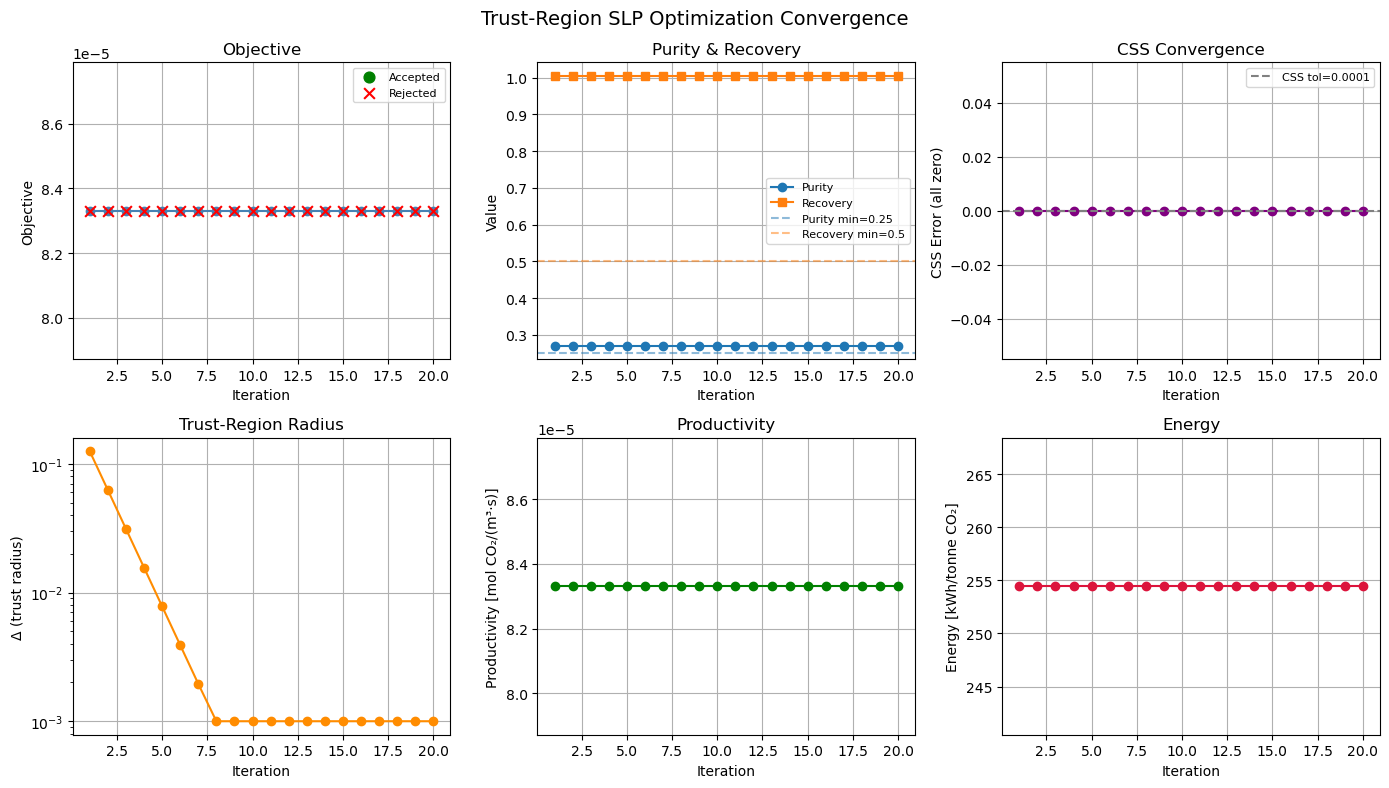

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Trust-Region SLP Optimization Convergence", fontsize=14)

accepted = df_last["accepted"].astype(bool)

# 1. Objective
ax = axes[0, 0]
ax.plot(df_last["iter"], df_last["objective"], marker="o", color="steelblue")
ax.scatter(df_last["iter"][accepted], df_last["objective"][accepted],
           color="green", zorder=5, label="Accepted", s=60)
ax.scatter(df_last["iter"][~accepted], df_last["objective"][~accepted],
           color="red", marker="x", zorder=5, label="Rejected", s=60)
ax.set_xlabel("Iteration"); ax.set_ylabel("Objective"); ax.set_title("Objective")
ax.legend(fontsize=8); ax.grid(True)

# 2. Purity & Recovery
ax = axes[0, 1]
ax.plot(df_last["iter"], df_last["purity"],    marker="o", label="Purity",    color="tab:blue")
ax.plot(df_last["iter"], df_last["recovery"],  marker="s", label="Recovery",  color="tab:orange")
ax.axhline(purity_min,   linestyle="--", color="tab:blue",   alpha=0.5, label=f"Purity min={purity_min}")
ax.axhline(recovery_min, linestyle="--", color="tab:orange", alpha=0.5, label=f"Recovery min={recovery_min}")
ax.set_xlabel("Iteration"); ax.set_ylabel("Value"); ax.set_title("Purity & Recovery")
ax.legend(fontsize=8); ax.grid(True)

# 3. CSS Error
ax = axes[0, 2]
css_vals = df_last["css_error"]
if css_vals.max() > 0:
    ax.plot(df_last["iter"], css_vals, marker="o", color="purple")
    ax.set_yscale("log")
else:
    ax.plot(df_last["iter"], css_vals, marker="o", color="purple")
    ax.set_ylabel("CSS Error (all zero)")
ax.axhline(css_tol, linestyle="--", color="gray", label=f"CSS tol={css_tol}")
ax.set_xlabel("Iteration"); ax.set_title("CSS Convergence")
ax.legend(fontsize=8); ax.grid(True)

# 4. Trust-region radius
ax = axes[1, 0]
ax.plot(df_last["iter"], df_last["delta"], marker="o", color="darkorange")
ax.set_xlabel("Iteration"); ax.set_ylabel("Δ (trust radius)"); ax.set_title("Trust-Region Radius")
ax.set_yscale("log")
ax.grid(True)

# 5. Productivity
ax = axes[1, 1]
ax.plot(df_last["iter"], df_last["productivity"], marker="o", color="green")
ax.set_xlabel("Iteration"); ax.set_ylabel("Productivity [mol CO₂/(m³·s)]"); ax.set_title("Productivity")
ax.grid(True)

# 6. Energy
ax = axes[1, 2]
ax.plot(df_last["iter"], df_last["energy"], marker="o", color="crimson")
ax.set_xlabel("Iteration"); ax.set_ylabel("Energy [kWh/tonne CO₂]"); ax.set_title("Energy")
ax.grid(True)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

units = {
    'L': 'm', 'P0': 'Pa', 'ndot': 'mol/s',
    'tads': 's', 'alpha': '—', 'beta': '—',
    'PI': 'Pa', 'Pl': 'Pa',
}

result = pd.DataFrame({
    "Variable":      VARIABLE_ORDER,
    "Optimal Value": [best_point[k] * SCALE[k] for k in VARIABLE_ORDER],
    "Unit":          [units[k] for k in VARIABLE_ORDER],
}).set_index("Variable")

result["Optimal Value"] = result["Optimal Value"].map(lambda x: f"{x:.4g}")
result

,Optimal Value,Unit
Variable,,
L,1,m
P0,1.075e+05,Pa
ndot,1.945,mol/s
tads,385.6,s
alpha,0.19,—
beta,0.353,—
PI,2.601e+04,Pa
Pl,7939,Pa


In [11]:
perf = pd.DataFrame({
    "Metric": ["Productivity", "Purity", "Recovery", "Energy", "Objective"],
    "Value": [
        f"{best_eval.productivity:.4f} mol CO₂/(m³·s)",
        f"{best_eval.purity:.4f}",
        f"{best_eval.recovery:.4f}",
        f"{best_eval.energy:.4f} kWh/tonne CO₂",
        f"{objective_value(best_eval, energy_weight):.4f}",
    ],
    "Constraint": [
        "—",
        f"≥ {purity_min}  {'✓' if best_eval.purity >= purity_min else '✗'}",
        f"≥ {recovery_min}  {'✓' if best_eval.recovery >= recovery_min else '✗'}",
        "—",
        "—",
    ]
}).set_index("Metric")

perf

,Value,Constraint
Metric,,
Productivity,0.0001 mol CO₂/(m³·s),—
Purity,0.2702,≥ 0.25 ✓
Recovery,1.0051,≥ 0.5 ✓
Energy,254.4495 kWh/tonne CO₂,—
Objective,0.0001,—
